# Setup

## Initial Params

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dadapy.metric_comparisons import MetricComparisons
import pickle
from joblib import Parallel, delayed
import scienceplots
import os

plt.style.use(["science", "ieee", "no-latex", "std-colors"])
plt.rcParams["font.size"] = 18
#!# https://www.tdistributiontable.com
#!# df==degrees of freedom = (n_ICs - 1)
#!# refer to the 'one-tail' column
T_999 = 3.852
T_995 = 3.012
T_99 = 2.650
colors = ["#1982c4", "black", "#ff595e", "#20b806"]

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
Ntrajs = 1000  # number of frames of interest in each trajectory
E = 1  # embedding dimension
tau_e = 1  # (in frames) 1 frame = 10 fs
discard_starting_frames = 500  # starting frame for each traj
frames_per_ps = 100  # number of frames of simulation that goes into 1 ps
tau_gap = 100  # how often we check for causality (in frames) == spacing between tau's
tau_start = 0  # the 'tau' to start from in the range of values in (taus)
tau_end = 10000  # max duration of time lag; 10K = 100 ps (in frames)
taus = np.arange(
    tau_start, tau_end, tau_gap
)  # 'tau' -$\\rightarrow$ how often to check for causality from initial starting frame
k = 5  # maximum number of neighbours to consider
nICs = 14  # number of initial conditions
dt = 0.01  # dt between each frame of simulation (in ps)
decorrelation_time = 30  # decorrelation time (in ps)
decorrelation_frames = int(decorrelation_time / dt)  # decorrelation time (in frames)
alphas = np.linspace(0.0, 1.0, 100)  # range of alphas, for the driving variable

print(f"Decorrelation time (in ps): {decorrelation_time}")
print(f"Decorrelation time (in frames): {decorrelation_frames}")
print(len(taus))

# Get the current directory
current_dir = os.getcwd()
figures_dir = current_dir + "/figures"

# Check if the directory exists
if not os.path.exists(figures_dir):
    # Create the directory
    os.makedirs(figures_dir)

print(current_dir)
print(figures_dir)

Decorrelation time (in ps): 30
Decorrelation time (in frames): 3000
100
/Users/dbanerje/Desktop/phd/3-causality_TRP/TRP/GS/gaff-opc/6-analysis/dihedral-vs-CN-smooth_no_embeddings
/Users/dbanerje/Desktop/phd/3-causality_TRP/TRP/GS/gaff-opc/6-analysis/dihedral-vs-CN-smooth_no_embeddings/figures


## IG + Error Functions

In [3]:
def compute_IG(iib_X_to_Y, iib_Y_to_X):
    assert iib_X_to_Y.shape == iib_Y_to_X.shape, "IIBs don't have same shape"

    n_ICs = iib_X_to_Y.shape[0]
    n_taus = iib_X_to_Y.shape[1]
    n_alphas = iib_X_to_Y.shape[2]

    ig_X_to_Y_indep = (
        100
        * (iib_X_to_Y[:, :, 0, np.newaxis] - iib_X_to_Y[:, :, :])
        / iib_X_to_Y[:, :, 0, np.newaxis]
    )
    ig_Y_to_X_indep = (
        100
        * (iib_Y_to_X[:, :, 0, np.newaxis] - iib_Y_to_X[:, :, :])
        / iib_Y_to_X[:, :, 0, np.newaxis]
    )

    #!# mean over all the initial conditions/independent samples (axis=0)
    ig_X_to_Y_mean = ig_X_to_Y_indep.mean(axis=0)
    ig_Y_to_X_mean = ig_Y_to_X_indep.mean(axis=0)
    ig_X_to_Y_err = ig_X_to_Y_indep.std(axis=0)
    ig_Y_to_X_err = ig_Y_to_X_indep.std(axis=0)

    #!# get alpha for which IG is maximum (last axis, axis=-1)
    alphas_X_to_Y = np.argmax(ig_X_to_Y_mean, axis=-1)
    alphas_Y_to_X = np.argmax(ig_Y_to_X_mean, axis=-1)

    #!# select the appropriate IG values for each relevant tau value
    ig_X_to_Y = ig_X_to_Y_mean[np.arange(n_taus), alphas_X_to_Y]
    ig_Y_to_X = ig_Y_to_X_mean[np.arange(n_taus), alphas_Y_to_X]

    error_X_to_Y = ig_X_to_Y_err[np.arange(n_taus), alphas_X_to_Y] / np.sqrt(n_ICs)
    error_Y_to_X = ig_Y_to_X_err[np.arange(n_taus), alphas_Y_to_X] / np.sqrt(n_ICs)

    #!# if IIB > 1.0, then set IG=0, since we always assume driven var is more informative about itself than driving var.
    ig_X_to_Y[np.where(iib_X_to_Y.mean(axis=0)[:, 0] > 1.0)] = 0.0
    ig_Y_to_X[np.where(iib_Y_to_X.mean(axis=0)[:, 0] > 1.0)] = 0.0
    error_X_to_Y[np.where(iib_X_to_Y.mean(axis=0)[:, 0] > 1.0)] = 0.0
    error_Y_to_X[np.where(iib_Y_to_X.mean(axis=0)[:, 0] > 1.0)] = 0.0

    return (
        ig_X_to_Y,
        ig_Y_to_X,
        error_X_to_Y,
        error_Y_to_X,
        alphas_X_to_Y,
        alphas_Y_to_X,
    )

In [4]:
def compute_Z_scores(values, errors):
    Z_score = +np.zeros(len(values))
    for i, _ in enumerate(values):
        if values[i] != 0:
            Z_score[i] = values[i] / errors[i]
    return Z_score

## Memory Allocation

In [5]:
iib_tor_to_cn = np.zeros((nICs, len(taus), len(alphas)))
iib_cn_to_tor = np.zeros((nICs, len(taus), len(alphas)))

In [6]:
for ic in range(nICs):
    for j, tau in enumerate(taus):
        (
            iib_tor_to_cn[ic, j, :],
            iib_cn_to_tor[ic, j, :],
        ) = pickle.load(
            open(f"{current_dir}/iib_data/iib_IC-{ic+1}_tau-{tau}_k-{k}.p", "rb")
        )

# Torsion Vec <-> CN Vec

## IG Analysis

In [7]:
final_time = 100  # in ps
final_time_index = final_time * frames_per_ps // tau_gap
taus_plot = taus[:final_time_index]

(
    IG_tor_to_cn,
    IG_cn_to_tor,
    error_tor_to_cn,
    error_cn_to_tor,
    alphas_tor_to_cn,
    alphas_cn_to_tor,
) = compute_IG(iib_tor_to_cn[:, :final_time_index], iib_cn_to_tor[:, :final_time_index])

# Statistically Significant Values according to t-test
Z_scores_tor_to_cn = compute_Z_scores(IG_tor_to_cn, error_tor_to_cn)
Z_scores_cn_to_tor = compute_Z_scores(IG_cn_to_tor, error_cn_to_tor)
mask_tor_to_cn = Z_scores_tor_to_cn > T_999
mask_cn_to_tor = Z_scores_cn_to_tor > T_999

# relative imbalance gain, k = 5, E = 50, tau_e = 1

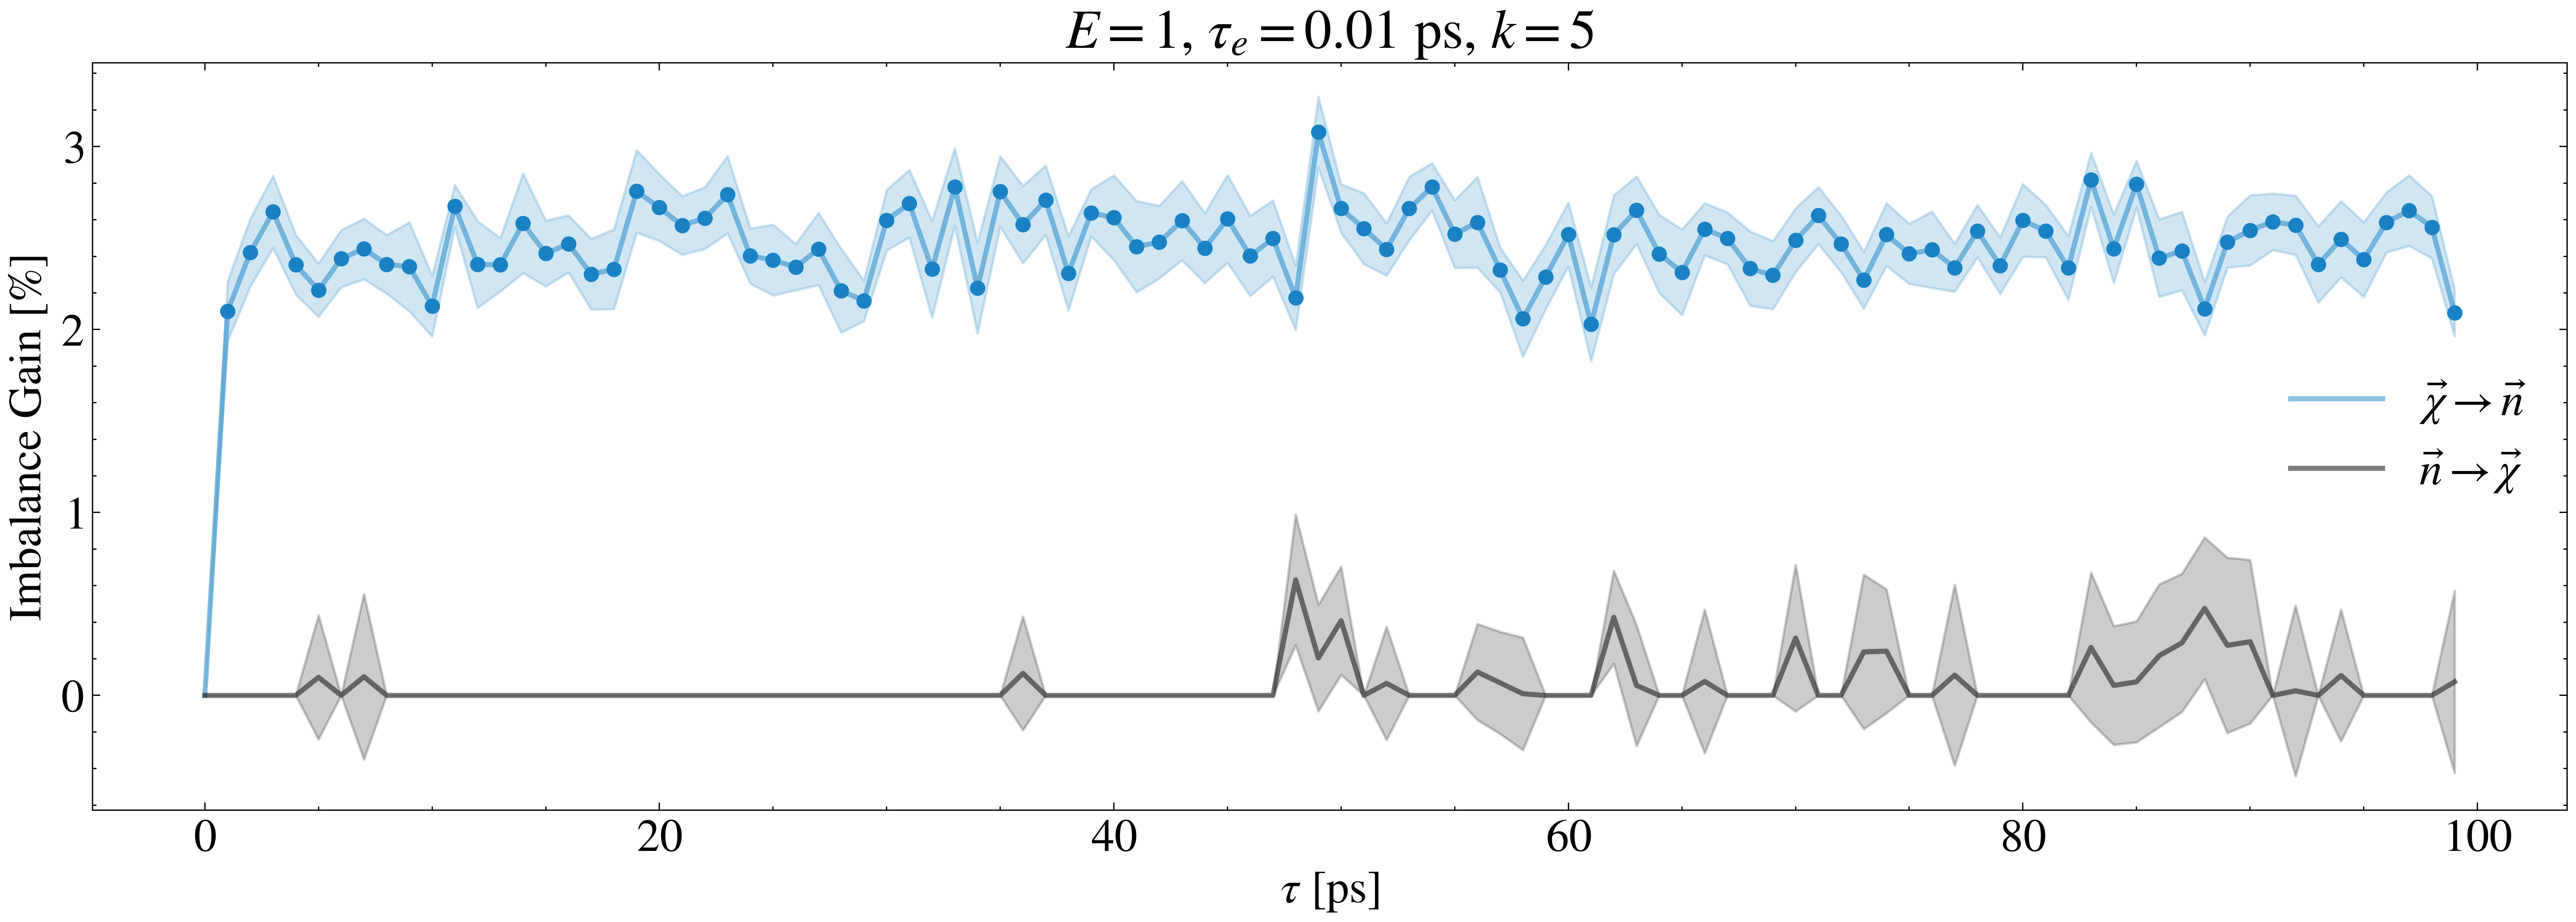

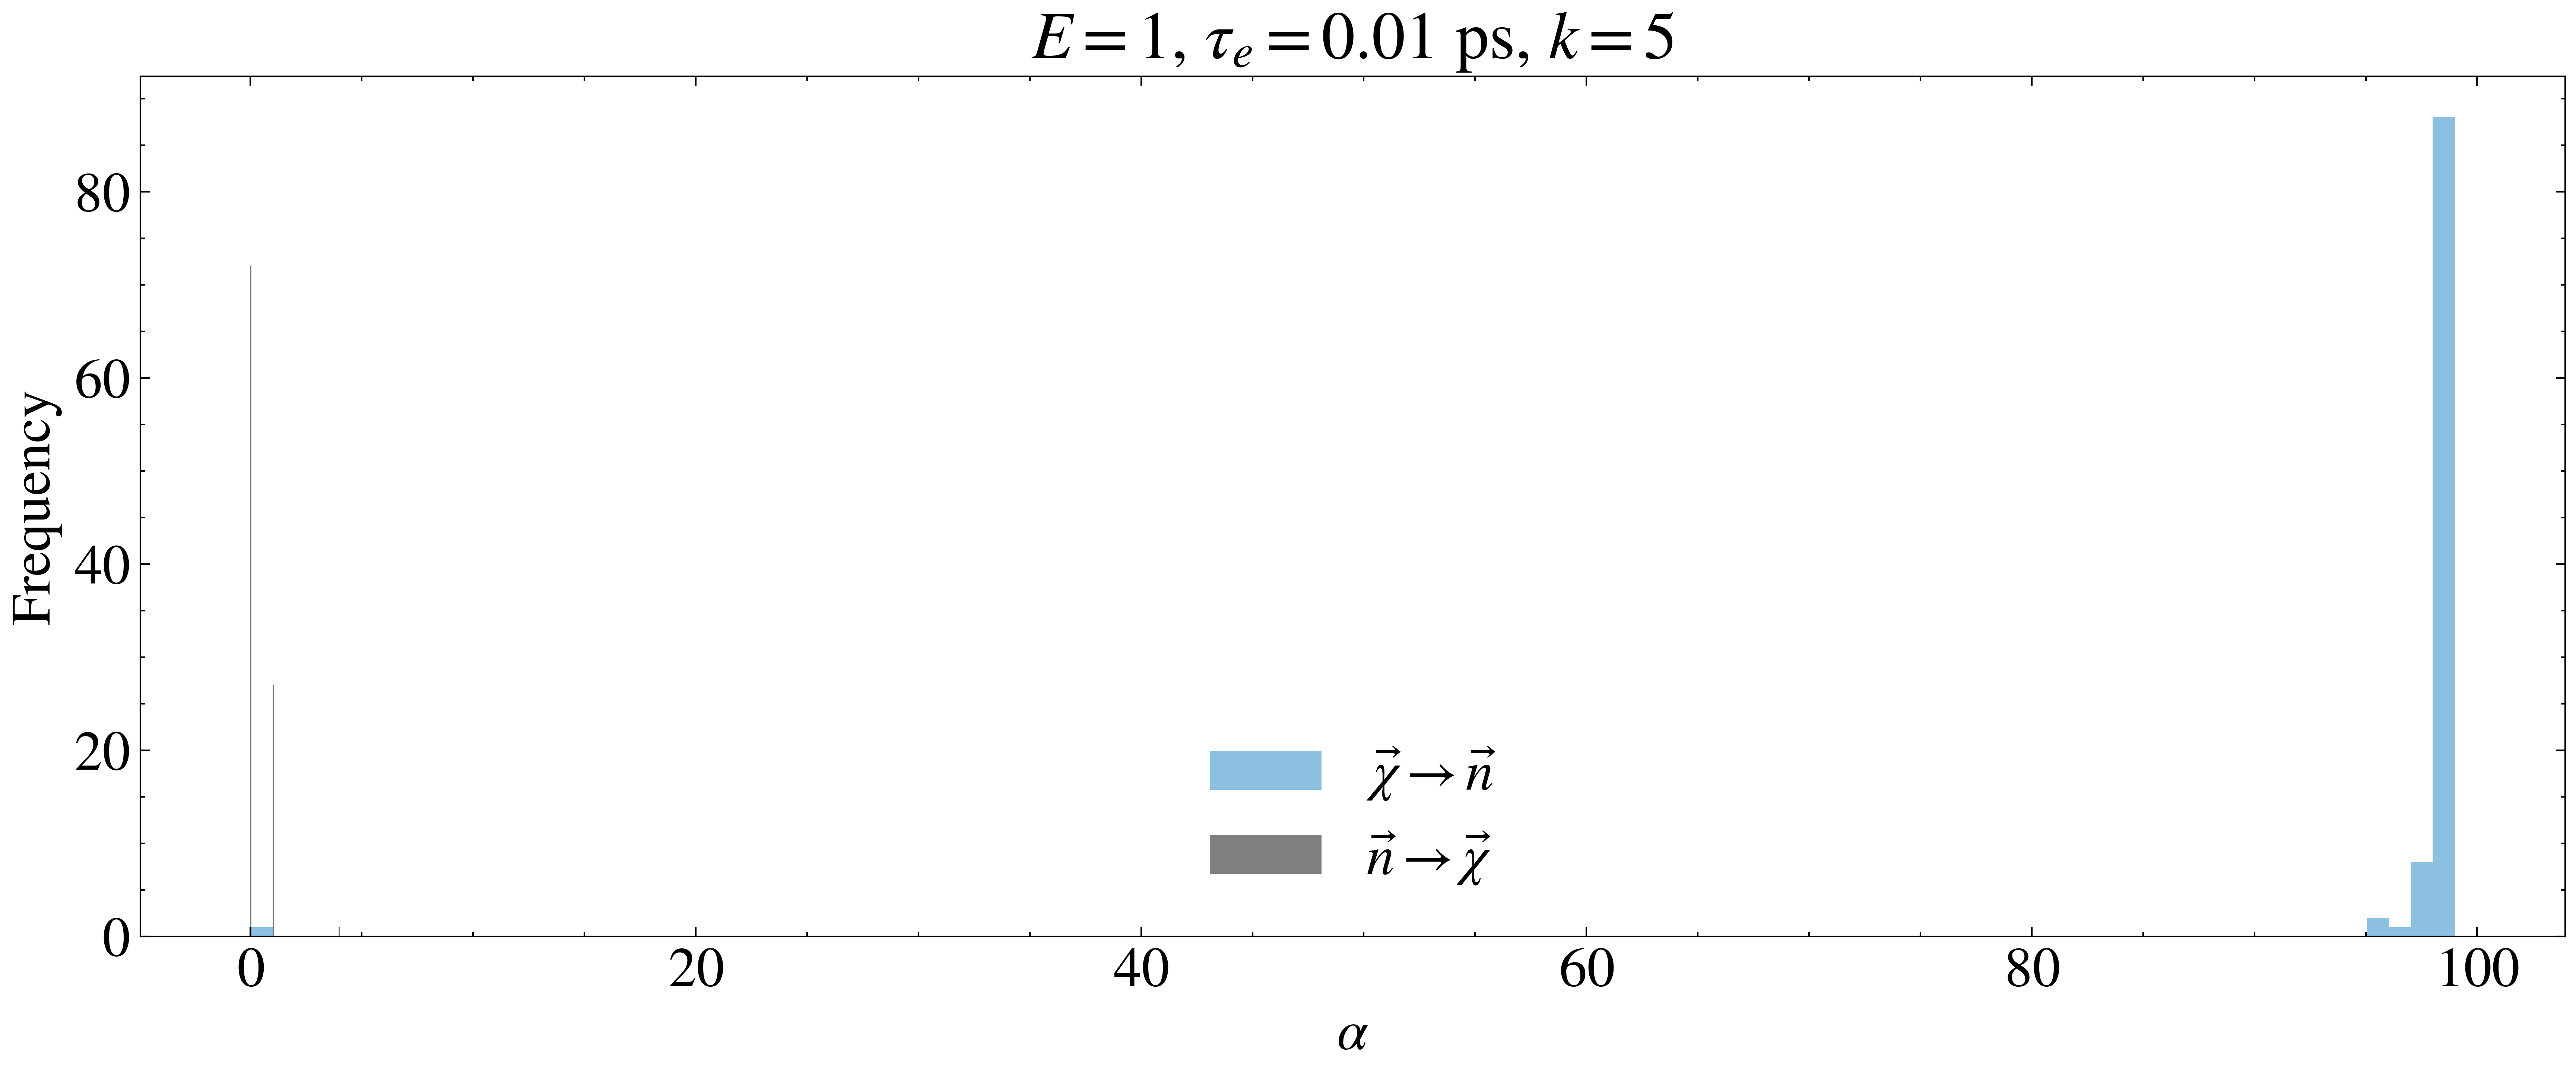

In [8]:
# Define the figure size and aspect ratio
fig_width = 14
fig_height = 5
fig_aspect = fig_width / fig_height

# Create a new figure with the desired aspect ratio
fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)

# Plot the data on the new figure
ax.plot(
    taus_plot / 100,
    IG_tor_to_cn,
    "-",
    label="$\\vec{\\chi} \\rightarrow \\vec{n}$",
    alpha=0.5,
    linewidth=2,
    color=colors[0],
)

ax.plot(
    taus_plot / 100,
    IG_cn_to_tor,
    "-",
    label="$\\vec{n} \\rightarrow \\vec{\\chi}$",
    alpha=0.5,
    linewidth=2,
    color=colors[1],
)

ax.plot(
    taus_plot[mask_tor_to_cn] / 100,
    IG_tor_to_cn[mask_tor_to_cn],
    "o",
    color=colors[0],
    markersize=5,
)
ax.plot(
    taus_plot[mask_cn_to_tor] / 100,
    IG_cn_to_tor[mask_cn_to_tor],
    "o",
    color=colors[1],
    markersize=5,
)

ax.fill_between(
    taus_plot / 100,
    IG_cn_to_tor - error_cn_to_tor,
    IG_cn_to_tor + error_cn_to_tor,
    alpha=0.2,
    color=colors[1],
)

ax.fill_between(
    taus_plot / 100,
    IG_tor_to_cn - error_tor_to_cn,
    IG_tor_to_cn + error_tor_to_cn,
    alpha=0.2,
    color=colors[0],
)

ax.legend()
ax.set_xlabel("$\\tau$ [ps]")
ax.set_ylabel("Imbalance Gain [%]")
ax.set_title(f"$E = {E}$, $\\tau_e = {tau_e/100:.2f}$ ps, $k = {k}$")

# Adjust the aspect ratio of the figure to fit the data
fig.set_size_inches(fig_width, fig_width / fig_aspect)
plt.savefig(f"{figures_dir}/IG_tor-vs-cn.png", dpi=300, bbox_inches="tight")

plt.figure(figsize=(14, 5))
plt.hist(
    alphas_tor_to_cn,
    bins=100,
    label="$\\vec{\\chi} \\rightarrow \\vec{n}$",
    alpha=0.5,
    color=colors[0],
)
plt.hist(
    alphas_cn_to_tor,
    bins=100,
    label="$\\vec{n} \\rightarrow \\vec{\\chi}$",
    alpha=0.5,
    color=colors[1],
)
plt.legend()
plt.title(f"$E = {E}$, $\\tau_e = {tau_e/100:.2f}$ ps, $k = {k}$")
plt.xlabel("$\\alpha$")
plt.ylabel("Frequency")
plt.savefig(f"{figures_dir}/alphas_tor-vs-cn.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
data_to_save = np.column_stack(
    [
        taus_plot / 100,
        IG_tor_to_cn,
        IG_cn_to_tor,
        mask_tor_to_cn,
        mask_cn_to_tor,
        error_tor_to_cn,
        error_cn_to_tor,
    ]
)
np.savetxt("IG-tor_vs_cn.txt", data_to_save)

data_to_save.shape

(100, 7)

## IIB Analysis

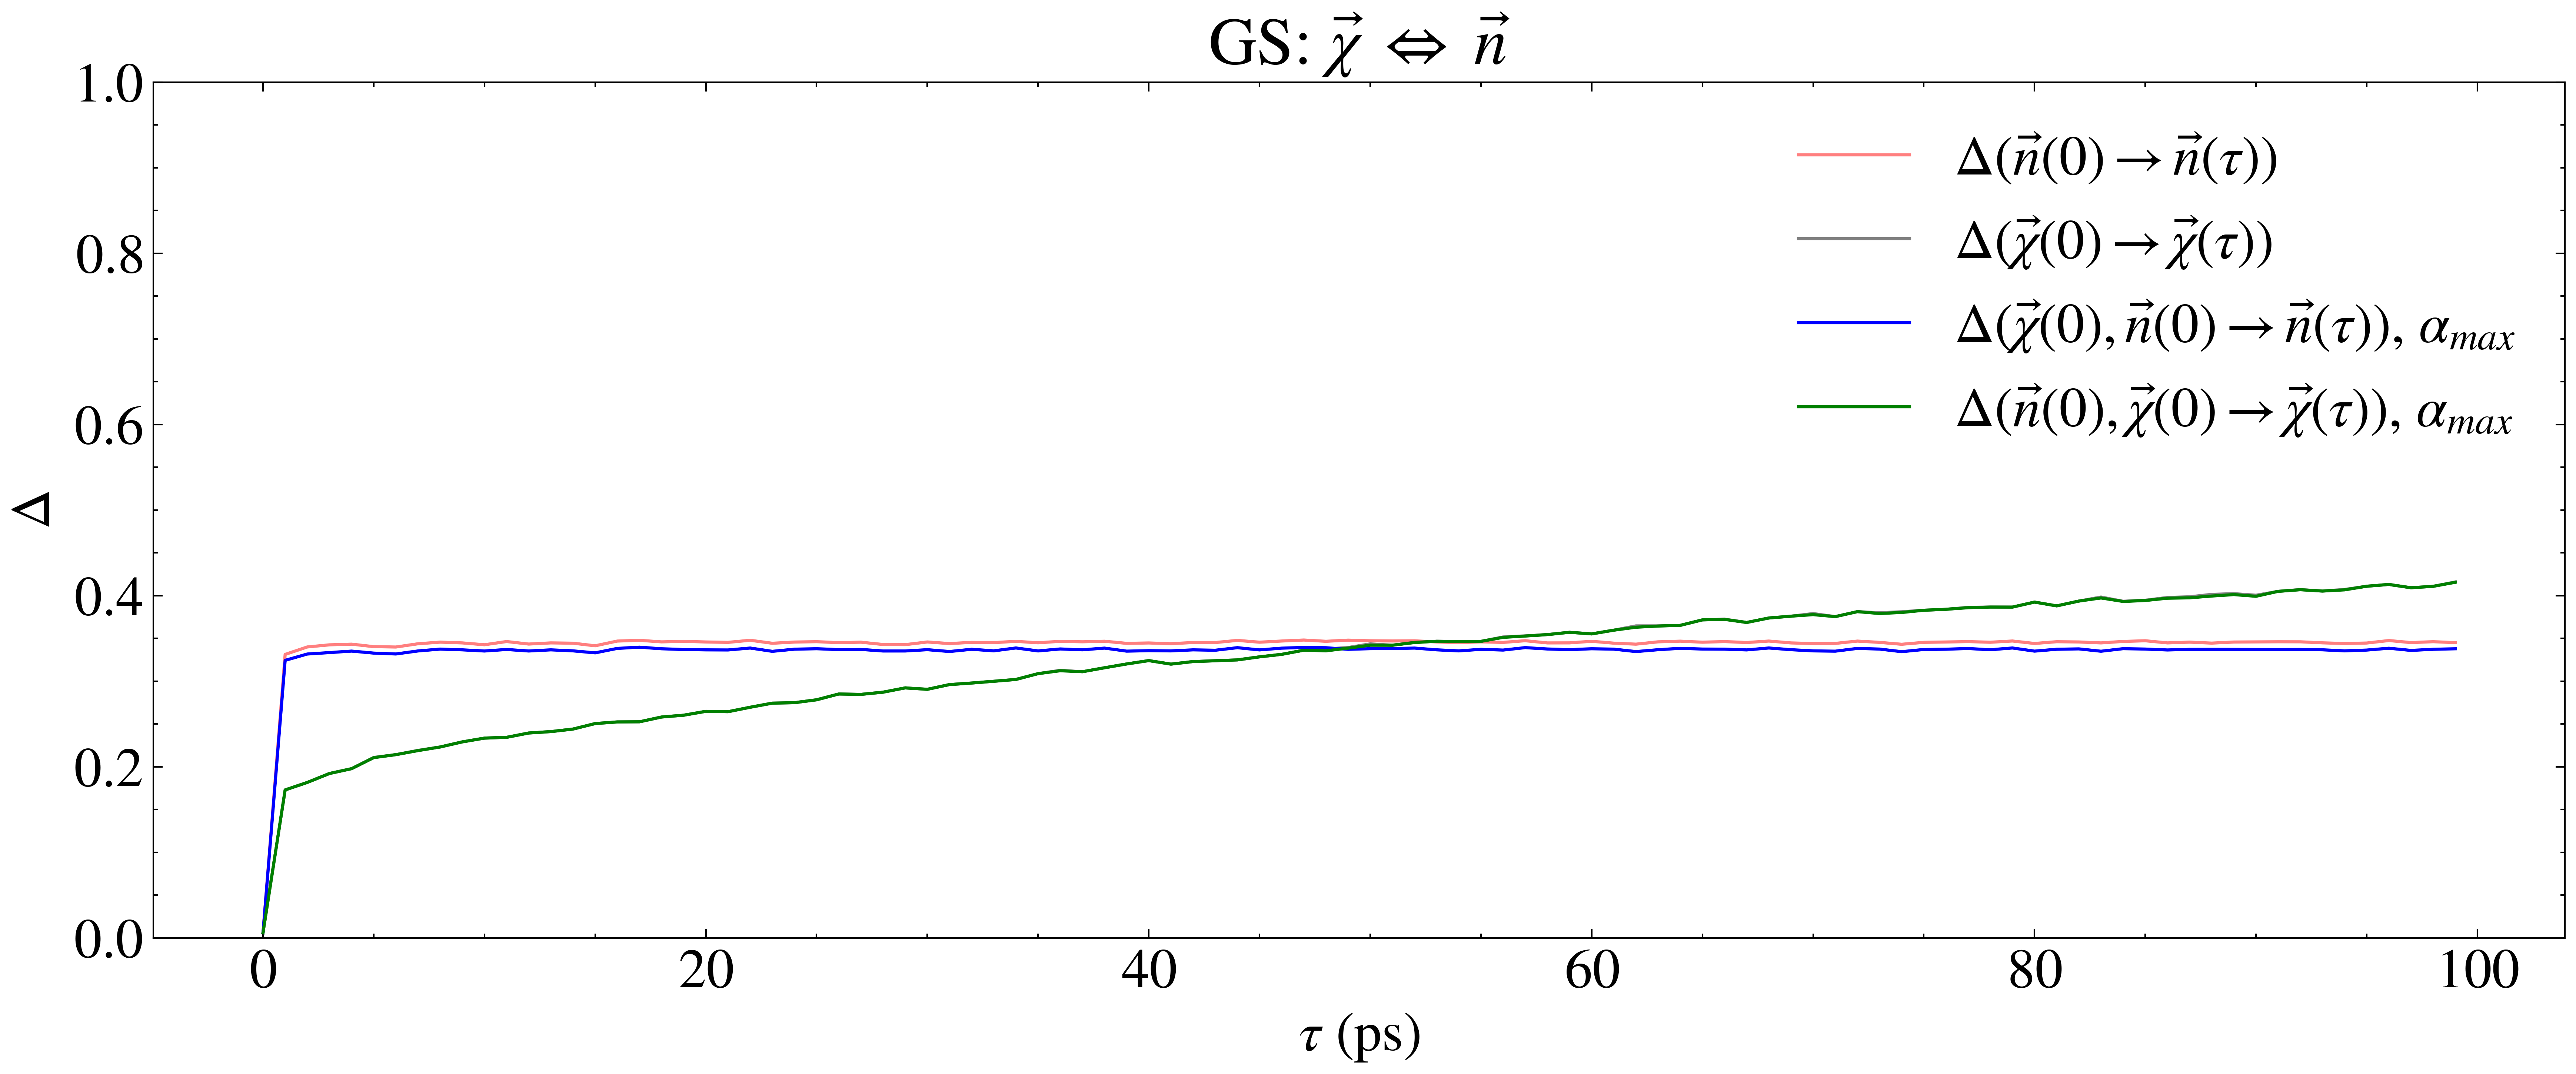

In [10]:
## The mean of IIB is chosen to average over all initial conditions

plt.figure(figsize=(14, 5))
plt.plot(
    taus_plot / 100,
    iib_tor_to_cn[:, :, 0].mean(axis=0),
    label="$\\Delta (\\vec{n} (0) \\rightarrow \\vec{n} (\\tau))$",
    color="red",
    linewidth=1.0,
    alpha=0.5,
)
plt.plot(
    taus_plot / 100,
    iib_cn_to_tor[:, :, 0].mean(axis=0),
    label="$\\Delta (\\vec{\\chi} (0) \\rightarrow \\vec{\\chi} (\\tau))$",
    color="black",
    linewidth=1.0,
    alpha=0.5,
)
plt.plot(
    taus_plot / 100,
    iib_tor_to_cn[:, np.arange(len(taus)), alphas_tor_to_cn].mean(
        axis=0
    ),  # the mean is chosen to get mean IIB over all initial conditions
    label="$\\Delta (\\vec{\\chi} (0), \\vec{n} (0) \\rightarrow \\vec{n} (\\tau))$, $\\alpha_{max}$",
    color="blue",
)
plt.plot(
    taus_plot / 100,
    iib_cn_to_tor[:, np.arange(len(taus)), alphas_cn_to_tor].mean(axis=0),
    label="$\\Delta (\\vec{n} (0), \\vec{\\chi} (0) \\rightarrow \\vec{\\chi} (\\tau))$, $\\alpha_{max}$",
    color="green",
)
plt.legend()
plt.ylim([0.0, 1.0])
plt.title("GS: $\\vec{\\chi}$ $\\Leftrightarrow$ $\\vec{n}$")
plt.ylabel("$\\Delta$")
plt.xlabel("$\\tau$ (ps)")
plt.savefig(f"{figures_dir}/IIB_tor-cn.png", dpi=300, bbox_inches="tight")